In [116]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set API key and city name
API_KEY =open('2_api_key.txt', 'r').read()
CITY = "Pune"
UNITS = "metric"  # Use "imperial" for Fahrenheit

# Fetch weather data from 5-day forecast API
url = f"https://api.openweathermap.org/data/2.5/forecast?q={CITY}&appid={API_KEY}&units={UNITS}"
response = requests.get(url)
data = response.json()

In [117]:
# Extract useful attributes from JSON response
weather_data = []
for entry in data["list"]:
    weather_data.append({
        "datetime": datetime.fromtimestamp(entry["dt"]),
        "temp": entry["main"]["temp"],
        "temp_min": entry["main"]["temp_min"],
        "temp_max": entry["main"]["temp_max"],
        "humidity": entry["main"]["humidity"],
        "pressure": entry["main"]["pressure"],
        "wind_speed": entry["wind"]["speed"],
        "weather": entry["weather"][0]["main"]
    })

# Convert to DataFrame
df = pd.DataFrame(weather_data)
df

,datetime,temp,temp_min,temp_max,humidity,pressure,wind_speed,weather
0,2025-11-06 05:30:00,21.72,20.07,21.72,84,1012,0.98,Rain
1,2025-11-06 08:30:00,21.82,21.82,22.02,82,1013,1.17,Clouds
2,2025-11-06 11:30:00,24.53,24.53,25.94,67,1013,2.99,Clouds
3,2025-11-06 14:30:00,27.89,27.89,27.89,50,1010,2.76,Clouds
4,2025-11-06 17:30:00,25.23,25.23,25.23,61,1011,2.40,Clouds
5,2025-11-06 20:30:00,24.49,24.49,24.49,61,1013,1.32,Clouds
6,2025-11-06 23:30:00,23.77,23.77,23.77,67,1013,0.69,Clouds
7,2025-11-07 02:30:00,23.11,23.11,23.11,69,1012,0.97,Clouds
8,2025-11-07 05:30:00,22.43,22.43,22.43,66,1013,2.18,Clouds
9,2025-11-07 08:30:00,23.16,23.16,23.16,58,1016,2.47,Clouds


In [118]:
# Clean and preprocess data
df.dropna(inplace=True)  # Remove missing records
df["date"] = df["datetime"].dt.date  # Add date column for aggregation
df

,datetime,temp,temp_min,temp_max,humidity,pressure,wind_speed,weather,date
0,2025-11-06 05:30:00,21.72,20.07,21.72,84,1012,0.98,Rain,2025-11-06
1,2025-11-06 08:30:00,21.82,21.82,22.02,82,1013,1.17,Clouds,2025-11-06
2,2025-11-06 11:30:00,24.53,24.53,25.94,67,1013,2.99,Clouds,2025-11-06
3,2025-11-06 14:30:00,27.89,27.89,27.89,50,1010,2.76,Clouds,2025-11-06
4,2025-11-06 17:30:00,25.23,25.23,25.23,61,1011,2.40,Clouds,2025-11-06
5,2025-11-06 20:30:00,24.49,24.49,24.49,61,1013,1.32,Clouds,2025-11-06
6,2025-11-06 23:30:00,23.77,23.77,23.77,67,1013,0.69,Clouds,2025-11-06
7,2025-11-07 02:30:00,23.11,23.11,23.11,69,1012,0.97,Clouds,2025-11-07
8,2025-11-07 05:30:00,22.43,22.43,22.43,66,1013,2.18,Clouds,2025-11-07
9,2025-11-07 08:30:00,23.16,23.16,23.16,58,1016,2.47,Clouds,2025-11-07


In [119]:
print("Initial Data Preview:")
print(df.head())

Initial Data Preview:
             datetime   temp  temp_min  temp_max  humidity  pressure  \
0 2025-11-06 05:30:00  21.72     20.07     21.72        84      1012   
1 2025-11-06 08:30:00  21.82     21.82     22.02        82      1013   
2 2025-11-06 11:30:00  24.53     24.53     25.94        67      1013   
3 2025-11-06 14:30:00  27.89     27.89     27.89        50      1010   
4 2025-11-06 17:30:00  25.23     25.23     25.23        61      1011   

   wind_speed weather        date  
0        0.98    Rain  2025-11-06  
1        1.17  Clouds  2025-11-06  
2        2.99  Clouds  2025-11-06  
3        2.76  Clouds  2025-11-06  
4        2.40  Clouds  2025-11-06  


In [120]:
print("\nData Info:")
df.info()


Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    40 non-null     datetime64[ns]
 1   temp        40 non-null     float64       
 2   temp_min    40 non-null     float64       
 3   temp_max    40 non-null     float64       
 4   humidity    40 non-null     int64         
 5   pressure    40 non-null     int64         
 6   wind_speed  40 non-null     float64       
 7   weather     40 non-null     object        
 8   date        40 non-null     object        
dtypes: datetime64[ns](1), float64(4), int64(2), object(2)
memory usage: 2.9+ KB


In [121]:
# Basic modeling and statistics
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
                  datetime       temp   temp_min   temp_max   humidity  \
count                   40  40.000000  40.000000  40.000000  40.000000   
mean   2025-11-08 16:00:00  22.716250  22.675000  22.756500  52.300000   
min    2025-11-06 05:30:00  17.250000  17.250000  17.250000  29.000000   
25%    2025-11-07 10:45:00  20.525000  20.355000  20.525000  44.000000   
50%    2025-11-08 16:00:00  22.670000  22.670000  22.670000  51.000000   
75%    2025-11-09 21:15:00  25.102500  25.102500  25.300000  61.000000   
max    2025-11-11 02:30:00  28.140000  28.140000  28.140000  84.000000   
std                    NaN   3.071633   3.096334   3.099552  12.683929   

          pressure  wind_speed  
count    40.000000   40.000000  
mean   1013.550000    1.470000  
min    1010.000000    0.490000  
25%    1012.000000    0.940000  
50%    1013.500000    1.330000  
75%    1015.000000    1.710000  
max    1017.000000    3.680000  
std       1.632208    0.726414  


In [122]:
print("\nAverage Temperature:", df["temp"].mean())


Average Temperature: 22.71625


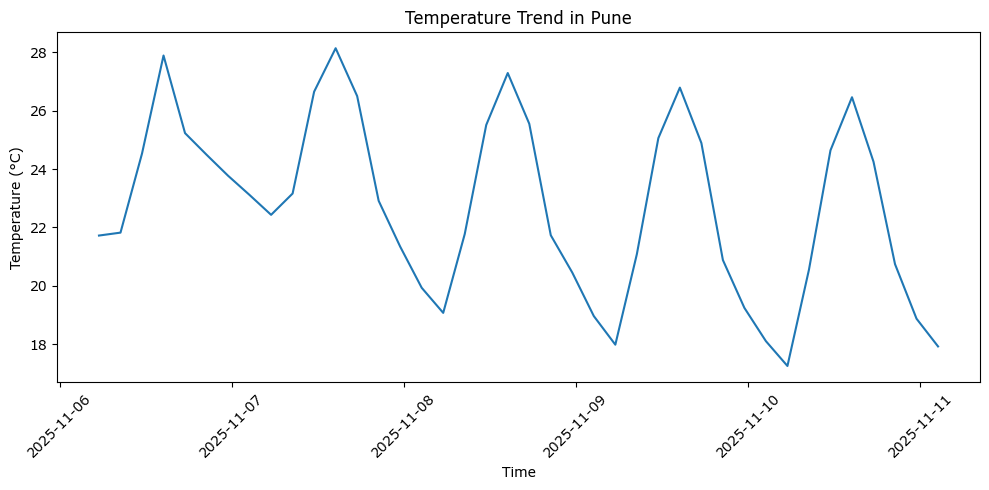

In [123]:
# Visualization 1: Temperature trend over time
plt.figure(figsize=(10,5))
plt.plot(df["datetime"], df["temp"])
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title(f"Temperature Trend in {CITY}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

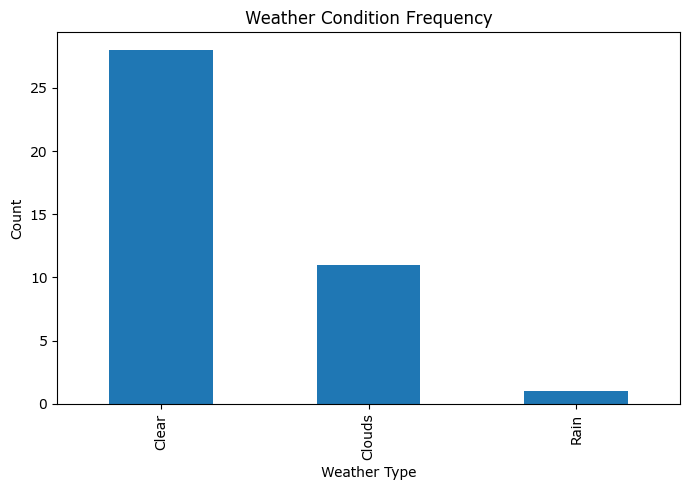

In [124]:
# Visualization 2: Weather condition counts
plt.figure(figsize=(7,5))
df["weather"].value_counts().plot(kind="bar")
plt.xlabel("Weather Type")
plt.ylabel("Count")
plt.title("Weather Condition Frequency")
plt.tight_layout()
plt.show()

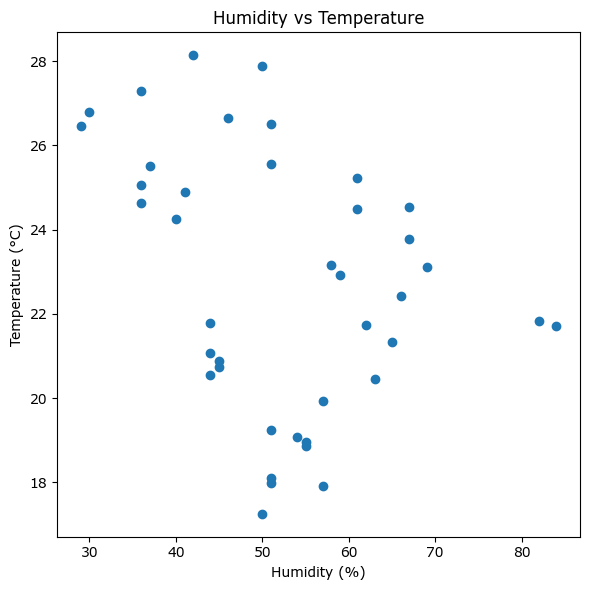

In [125]:
# Visualization 3: Humidity vs Temperature
plt.figure(figsize=(6,6))
plt.scatter(df["humidity"], df["temp"])
plt.xlabel("Humidity (%)")
plt.ylabel("Temperature (°C)")
plt.title("Humidity vs Temperature")
plt.tight_layout()
plt.show()

In [126]:
# Aggregation: Daily statistics
daily_stats = df.groupby("date").agg({
    "temp": ["mean", "min", "max"],
    "humidity": "mean",
    "wind_speed": "mean"
})
print("\nDaily Aggregated Weather Statistics:")
print(daily_stats)


Daily Aggregated Weather Statistics:
                 temp                 humidity wind_speed
                 mean    min    max       mean       mean
date                                                     
2025-11-06  24.207143  21.72  27.89  67.428571   1.758571
2025-11-07  24.280000  21.34  28.14  57.000000   1.866250
2025-11-08  22.662500  19.07  27.29  50.500000   1.408750
2025-11-09  21.860000  17.98  26.79  44.125000   1.176250
2025-11-10  21.357500  17.25  26.46  43.750000   1.298750
2025-11-11  17.920000  17.92  17.92  57.000000   0.490000


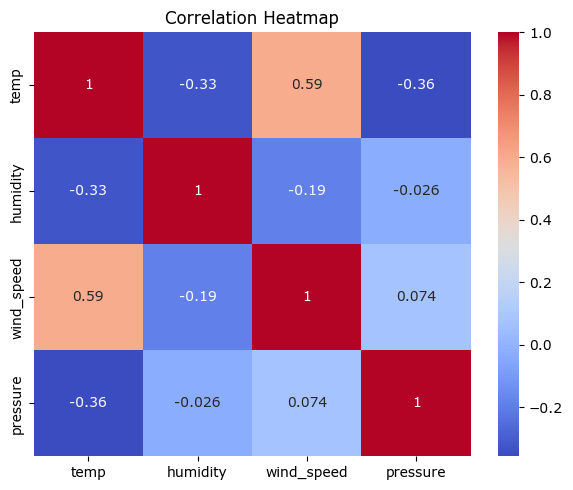

In [127]:
# Correlation analysis
plt.figure(figsize=(6,5))
sns.heatmap(df[["temp", "humidity", "wind_speed", "pressure"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [128]:
# Export cleaned dataset for future modeling
df.to_csv("weather_cleaned.csv", index=False)
print("\nCleaned dataset saved as weather_cleaned.csv")


Cleaned dataset saved as weather_cleaned.csv
